In [1]:
import os, sys
# nbconvert runs with cwd = notebooks/; the src modules (and this notebook's
# own path references below) assume the project root instead.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

# 03 — Explainability & Cost-Optimized Threshold

Two questions this notebook answers:
1. **Why** does the model think a customer will churn? (SHAP)
2. **At what predicted probability should we actually act?** (cost-based threshold optimization, then a calibration audit of that result)

This second question is the centerpiece of the project: the default 0.5 threshold is an artifact of the sigmoid, not a business decision.

In [2]:
import sys
sys.path.insert(0, '..')
import json
import joblib
import numpy as np
import pandas as pd
from IPython.display import Image
from src.evaluate import OFFER_COST, LTV, EFFECTIVENESS, analytical_optimal_threshold

## SHAP explainability

Run from the project root: `python -m src.explain`. Loading the resulting figures and rankings here.

In [3]:
ranking = pd.read_csv('reports/shap_ranking.csv', index_col=0).squeeze()
ranking.head(10)

cat__Contract_Month-to-month           0.670545
num__tenure                            0.455422
num__MonthlyCharges                    0.269057
cat__OnlineSecurity_No                 0.244264
num__TotalCharges                      0.240314
cat__InternetService_Fiber optic       0.214680
cat__TechSupport_No                    0.208416
cat__PaymentMethod_Electronic check    0.185051
cat__Contract_Two year                 0.143132
cat__PaperlessBilling_Yes              0.122128
Name: 0, dtype: float64

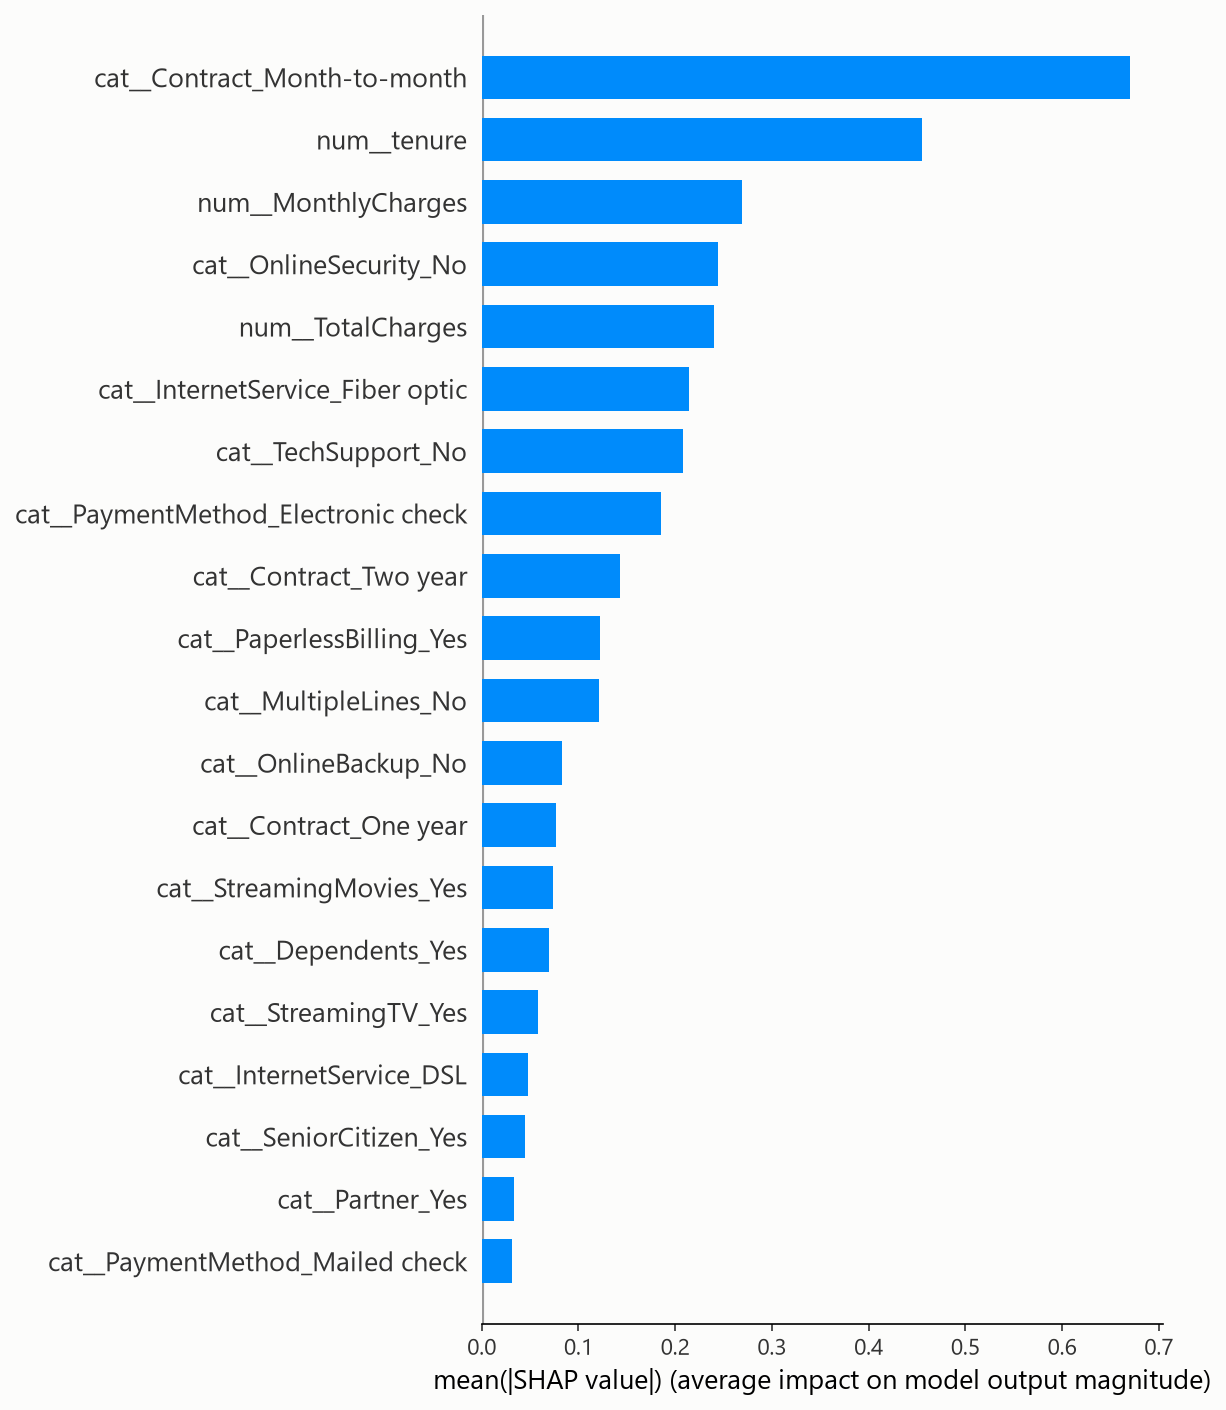

In [4]:
Image('reports/figures/shap_bar.png')

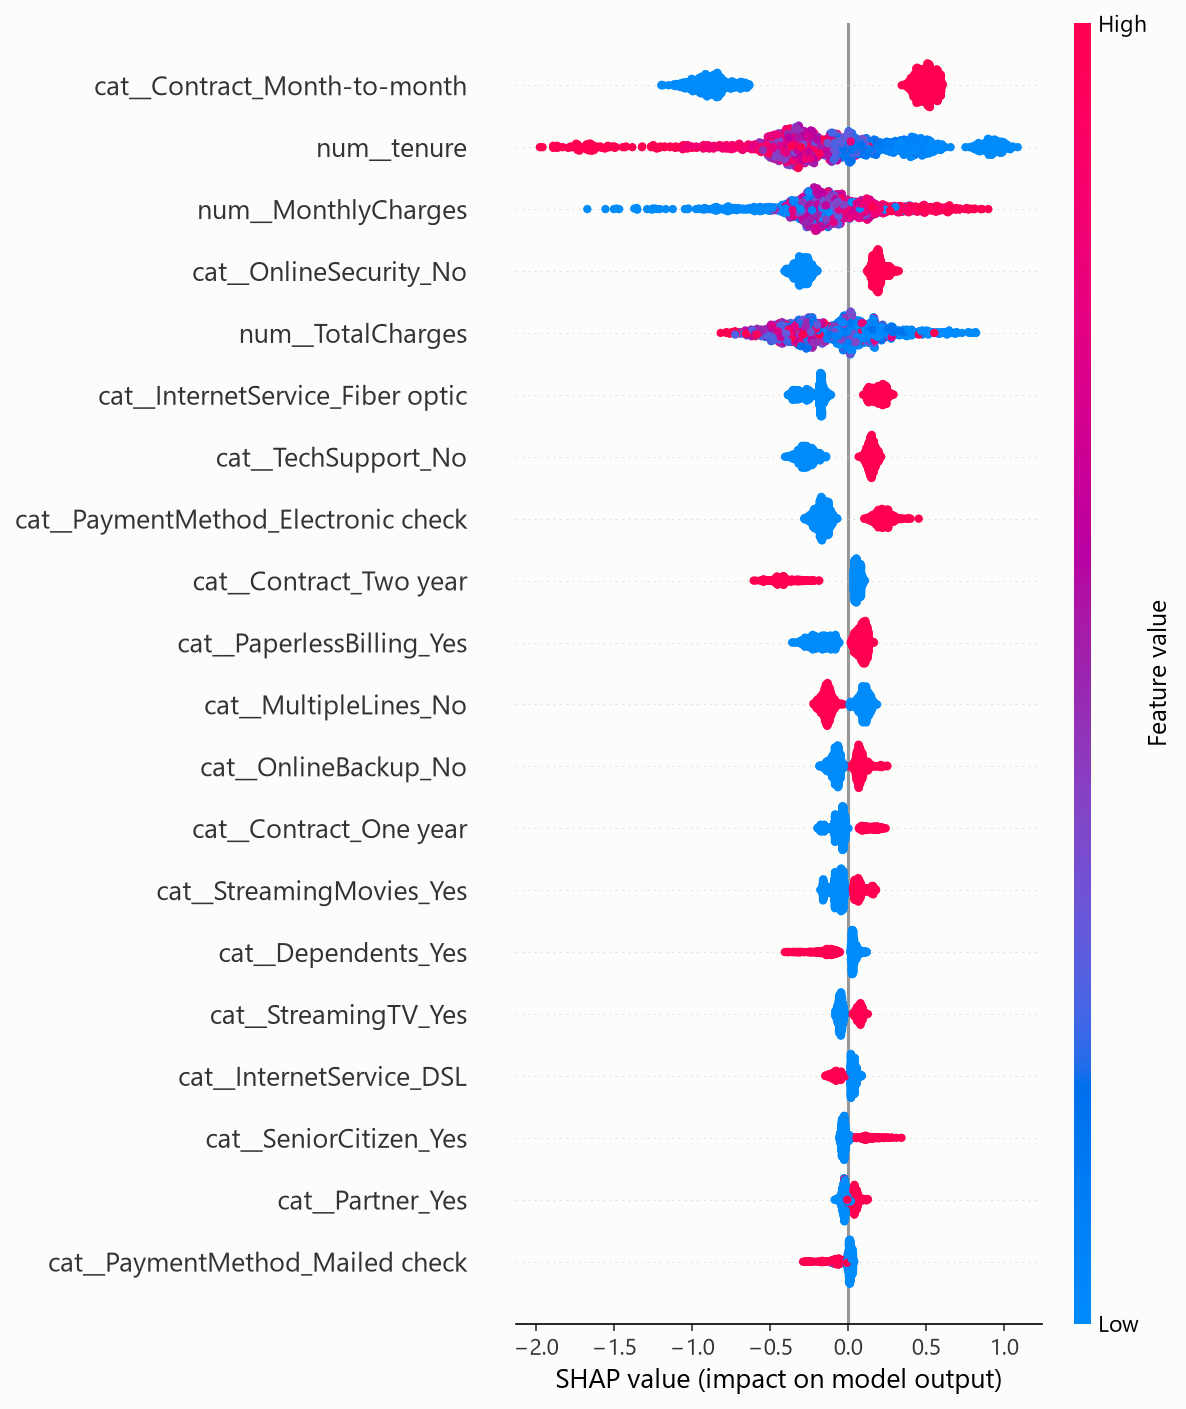

In [5]:
Image('reports/figures/shap_summary.png')

The beeswarm confirms direction, not just magnitude: month-to-month contract, low tenure, and no online security push predictions *toward* churn; long tenure and two-year contracts push *away* from it.

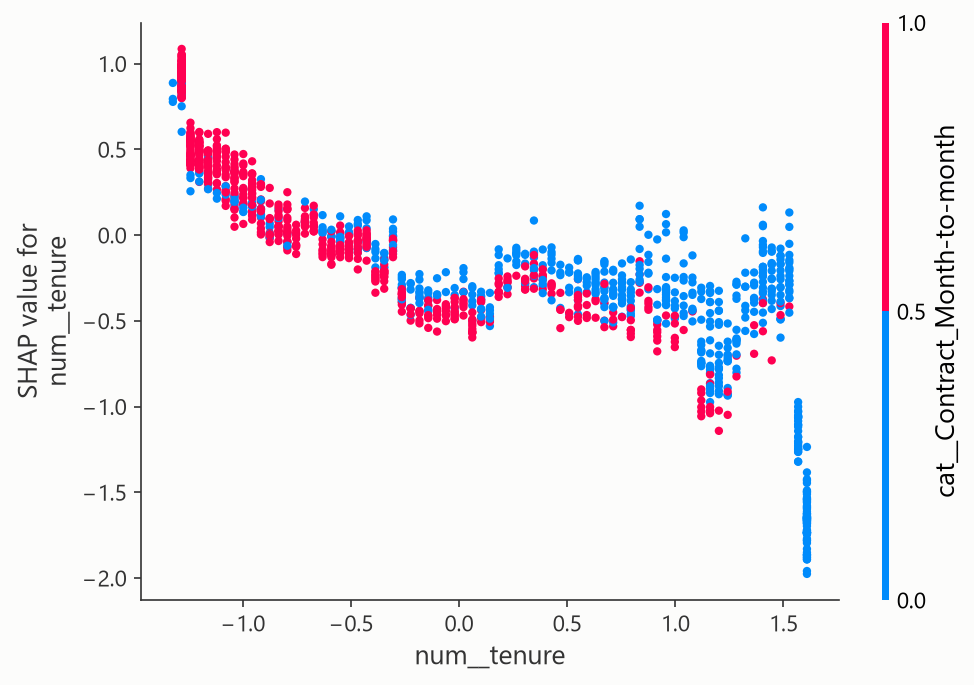

In [6]:
Image('reports/figures/shap_tenure.png')

### From SHAP output to business recommendations

SHAP output is an input to a finding, not a finding by itself. Translated:

1. **Contract type dominates.** `Contract_Month-to-month` carries the single largest mean |SHAP| contribution in the model. Migrating even 10% of the month-to-month base to an annual contract via a discount incentive addresses the largest identifiable risk pool.
2. **Risk concentrates in the first year.** `tenure` is the second-ranked feature and, per the EDA in notebook 01, churn probability falls sharply after ~12 months. Retention spend is more efficient front-loaded into onboarding than spread evenly.
3. **Fiber optic is an independent risk factor**, not fully explained by `MonthlyCharges` -- it ranks separately in the SHAP importance list. This is inconsistent with a purely price-driven explanation and points at a service-quality or expectation-setting problem. **Next step:** pull support-ticket volume and outage data by service type -- the churn model can flag the pattern but cannot explain *why* it happens.

## Cost-based threshold optimization

### The economics

| Parameter | Value | Meaning |
|---|---|---|
| `OFFER_COST` | $50 | Cost of extending a retention offer |
| `LTV` | $1400 | Customer lifetime value lost if they churn |
| `EFFECTIVENESS` | 0.3 | Fraction of would-be churners the offer actually saves |

**Cost per outcome:**
- True positive (churner, we intervene): `OFFER_COST + (1-EFFECTIVENESS)*LTV` = $50 + 0.70x1400 = **$1,030**
- False negative (churner, no intervention): **$1,400**
- False positive (loyal customer, wasted offer): **$50**
- True negative: **$0**

### The analytical answer first

Intervene on a customer with churn probability *p* when expected benefit exceeds cost: `p * EFFECTIVENESS * LTV > OFFER_COST`, i.e. `p > OFFER_COST / (EFFECTIVENESS * LTV)`.

In [7]:
t_analytical = analytical_optimal_threshold()
print(f'Analytical optimal threshold: {t_analytical:.4f}')

Analytical optimal threshold: 0.1190


### Empirical confirmation

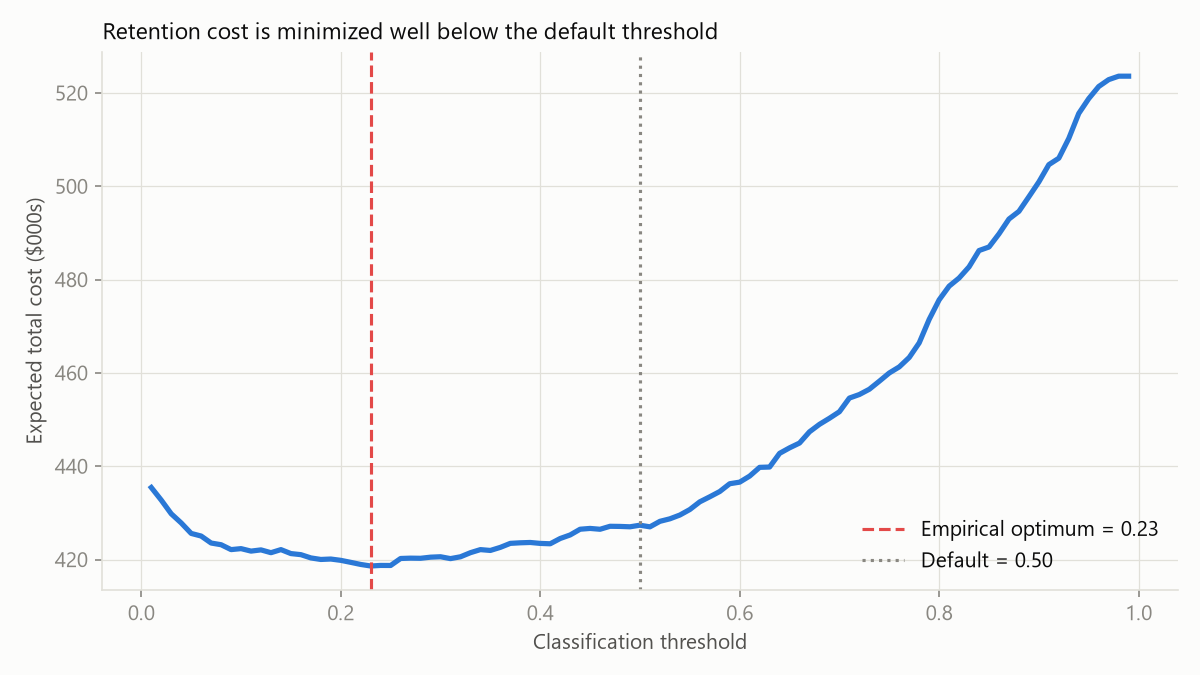

In [8]:
Image('reports/figures/threshold_cost_curve.png')

In [9]:
with open('reports/train_summary.json') as f:
    summary = json.load(f)
print('Empirical optimal threshold (uncalibrated XGBoost):', summary['empirical_optimal_threshold'])
print('Cost at empirical optimum: ${:,.0f}'.format(summary['empirical_optimal_cost']))
print('Cost at default 0.50:      ${:,.0f}'.format(summary['default_threshold_cost']))

Empirical optimal threshold (uncalibrated XGBoost): 0.23
Cost at empirical optimum: $418,620
Cost at default 0.50:      $427,360


The empirical optimum (0.23) sits noticeably above the analytical prediction (0.12) -- a real gap, not rounding noise. That gap turns out to matter: the calibration audit below traces it to a specific cause rather than leaving it unexplained.

### Sensitivity analysis

The three cost parameters are assumptions. Sweeping them shows how much the recommendation actually depends on getting them exactly right.

In [10]:
sens = pd.read_csv('reports/sensitivity.csv', index_col=0)
sens

,800,1400,2200
effectiveness,,,
0.15,0.76,0.51,0.25
0.30,0.41,0.23,0.09
0.50,0.23,0.09,0.09


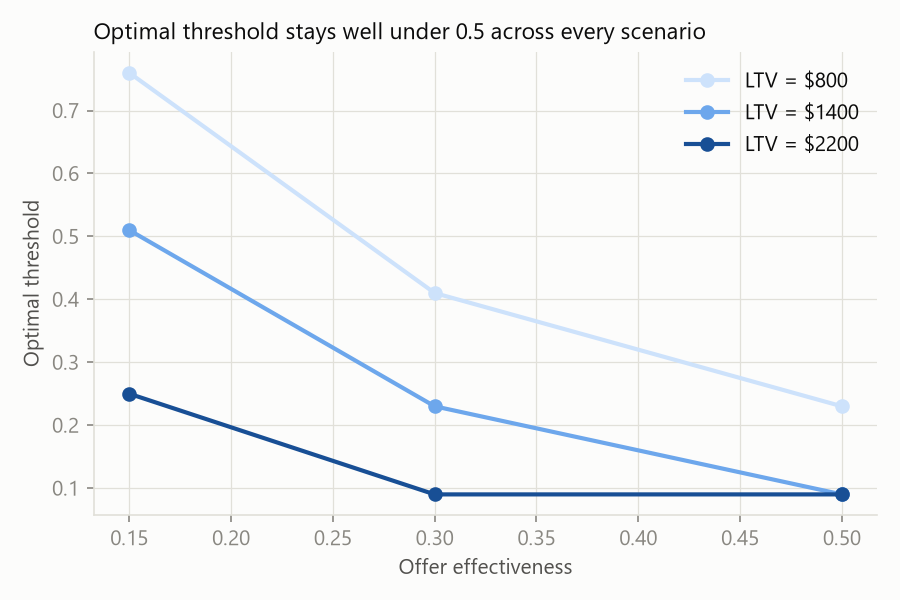

In [11]:
Image('reports/figures/threshold_sensitivity.png')

**Honest reading:** the optimal threshold is *not* uniformly low. At low offer effectiveness (15%) combined with low LTV ($800), the cost-minimizing threshold rises as high as 0.76 -- close to never intervening, because a cheap, low-value customer saved by a weak offer barely clears the cost of the offer itself. The threshold only stays comfortably below the 0.5 default when effectiveness and/or LTV are moderate-to-high, which is the plausible region for this business case -- but the recommendation is conditional on that, not universal, and the sensitivity table is what makes that visible instead of assumed.

## Calibration audit

Everything above assumes predicted probabilities are literal frequencies -- that a customer scored at 0.30 churns 30% of the time. Boosted trees trained with `scale_pos_weight` are notoriously miscalibrated, so this audits that assumption directly rather than taking it on faith.

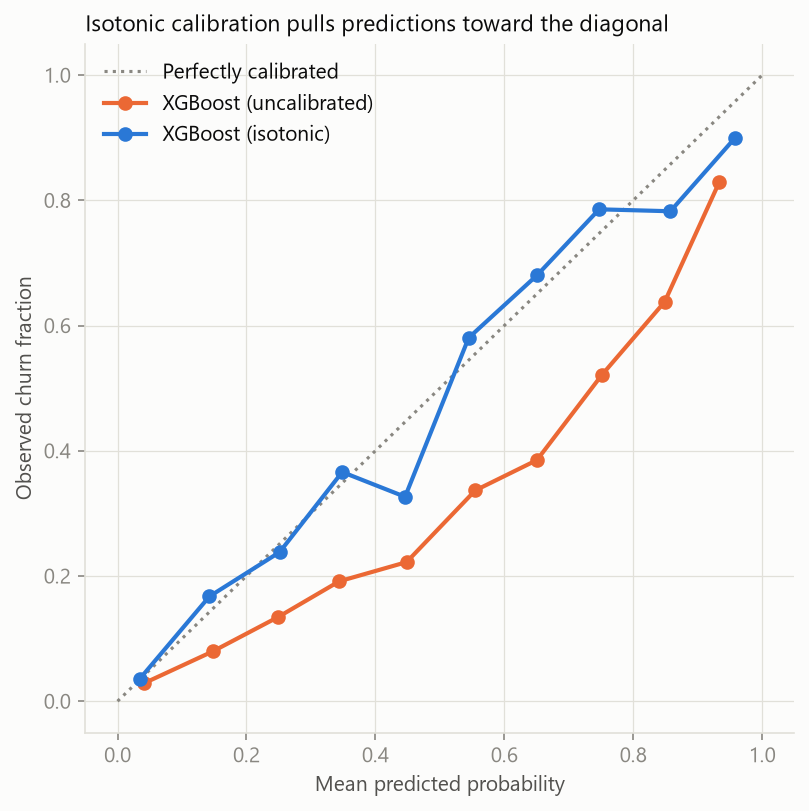

In [12]:
Image('reports/figures/calibration.png')

In [13]:
with open('reports/calibration_summary.json') as f:
    cal = json.load(f)
print(f"Brier score, uncalibrated: {cal['brier_uncalibrated']:.4f}")
print(f"Brier score, isotonic:     {cal['brier_calibrated']:.4f}")
print()
print(f"Optimal threshold, uncalibrated probabilities: {cal['optimal_threshold_uncalibrated']}")
print(f"Optimal threshold, calibrated probabilities:   {cal['optimal_threshold_calibrated']}")

Brier score, uncalibrated: 0.1627
Brier score, isotonic:     0.1357

Optimal threshold, uncalibrated probabilities: 0.23
Optimal threshold, calibrated probabilities:   0.13


**This resolves the gap noted earlier.** The uncalibrated model's empirical optimum (0.23) was pulled away from the analytical prediction (0.12) by miscalibration. After isotonic calibration (Brier score 0.163 -> 0.136), the empirical optimum shifts to **0.13** -- almost exactly the analytical value. The divergence was a calibration artifact, not a real economic effect, and the audit is what tells the two apart instead of leaving it as an unexplained discrepancy.

In [14]:
import joblib, pandas as pd
art = joblib.load('models/churn_model.joblib')
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
from src.evaluate import expected_cost
proba_cal = art['model'].predict_proba(X_test)[:, 1]
cost_default = expected_cost(y_test, proba_cal, 0.5)
cost_opt = expected_cost(y_test, proba_cal, art['threshold'])
n_test = len(y_test)
savings_per_customer = (cost_default - cost_opt) / n_test
print(f"Production model: calibrated XGBoost, threshold={art['threshold']}")
print(f"Cost at default 0.50:            ${cost_default:,.0f}")
print(f"Cost at calibrated optimum {art['threshold']}:   ${cost_opt:,.0f}")
print(f"Savings per customer:            ${savings_per_customer:,.2f}")
print(f"Annualized @ 50,000 customers:    ${savings_per_customer*50_000:,.0f}")

Production model: calibrated XGBoost, threshold=0.13
Cost at default 0.50:            $451,570
Cost at calibrated optimum 0.13:   $418,050
Savings per customer:            $23.79
Annualized @ 50,000 customers:    $1,189,496


## Headline result

The model deployed in `models/churn_model.joblib` is the **isotonic-calibrated XGBoost**, operating at threshold **0.13** rather than the default 0.50. Against the retention economics above, that is worth roughly **$1.19M annually** at a 50,000-customer base versus leaving the threshold at 0.5 -- and the derivation (closed-form -> empirical sweep -> calibration audit -> sensitivity check) is reproducible end to end, not a single plugged-in number.

## Limitations and next steps

**Predicting who will churn is not the same question as predicting who to target.** Some high-risk customers will leave regardless of any offer -- spending retention budget on them is waste ("lost causes"). Others would have stayed quietly and churn *because* a retention email reminded them they have a subscription to cancel ("sleeping dogs") -- targeting them is actively harmful, not just wasteful. Risk ranking, which is everything this project has done so far, cannot distinguish either group from a genuine "persuadable."

The Telco dataset has no randomized treatment variable, so a true uplift model cannot be fit on it honestly, and this project does not pretend otherwise. What would resolve it: a randomized holdout where a deliberately withheld fraction of high-risk customers receives no offer, generating the treatment/control contrast an uplift model needs (a two-model T-learner, evaluated by Qini AUC, is the standard approach -- see the Hillstrom or Criteo uplift datasets for a worked example on data that actually supports it). Until that data exists, the honest framing of this project's targeting rule is *risk-based*, not *uplift-based* -- and the EFFECTIVENESS parameter in the cost model above is this project's explicit acknowledgment that not every intervention converts, even though it cannot yet say *which* customers convert.